# This notebook is based on the following lecture:

https://www.youtube.com/watch?v=h6UpsLI4Ejg&t=2894s

Github: https://github.com/DerAndr/machine_learning_course_basics/blob/main/lectures/lecture_02_data_preparation_part_1/practical_session/data_preparation_part1_practical_student_90min.ipynb

The github link does not matches the lecture though, but can be used as reference; its from the same author

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import numpy as np
import scipy
from collections import Counter
from pathlib import Path

In [ ]:
#dataset path
data_path = Path('/content/drive/MyDrive/Career/Courses/EDA')
dataset_path = data_path/'AmesHousing.csv'

In [ ]:
#get the dataset into pandas
df = pd.read_csv(dataset_path, na_values='NA', index_col='Order') # converts the NA entries to NaN in the dataframe

In [ ]:
df.head(10)

In [ ]:
#show elements of the first row as dictionary
df.iloc[0].to_dict() #iloc stands for integer location-it selects rows and columns by their numeric position (index number), not by label.
#df.iloc[0]	Select the first row (position 0) of the DataFrame


In [ ]:
#get basic info about the dataset
df.info() # gives how many rows and columns, list of column headings, how many non null entries in each column and datatype

In [ ]:
#get statistics
df.describe()

In [ ]:
#get stat for one field
df.describe()['Lot Area']

In [ ]:
#show stat for field of type==object
df.describe(include='object') #generates summary statistics for all columns with categorical/text data (dtype object) in your DataFrame, instead of the default numeric columns.


In [ ]:
df.describe(include=[np.number])

In [ ]:
df.dtypes

# Measuring central tendency: through writing functions and also using default numpy and pandas functions

In [ ]:
# calculate mean, median. mode with custom function
def _mean(data):
  return sum(data)/len(data)

def _median(data):
  sorted_values = sorted(data)
  mid_index = len(sorted_values)//2 # for both even and odd case, it gives the same mid index: if len=4, mid=2, if len=5, mid=2
  return (sorted_values[mid_index] + sorted_values[-mid_index-1])/2 # if len is odd, both mid_index and [-mid_index-1] gives the same index, so same number a the middle

def _mode(data):
  counter = Counter(data) # Counter returns a dict
  return counter.most_common(1)[0][0] # most_common(1) returns a list of tuples containing (value, count); we need value

mean = _mean(df.SalePrice)
median = _median(df.SalePrice)
mode = _mode(df.SalePrice)

print('Mean:', mean)
print('median:', median)
print('mode:', mode)



In [ ]:
# mean, median, mode with pandas
mean = df.SalePrice.mean()
median = df.SalePrice.median()
mode = df.SalePrice.mode()

print('mean:', mean, 'median:', median, 'mode:', mode)



# Measure Spread

In [ ]:
# using numpy
std = np.std(df.SalePrice)
var = np.var(df.SalePrice)
print('variance:', var, 'std:', std)

In [ ]:
#using pandas
std = df.SalePrice.std()
var = df.SalePrice.var()
std_biased = df.SalePrice.std(ddof=0)
var_biased = df.SalePrice.var(ddof=0)
print('variance:', var, 'std:', std, 'var_b:', var_biased, 'std_b:', std_biased)

Indicator of distribution shape: skewness, Kurtosis

In [13]:
# with panda
skew = df.SalePrice.skew()
kurt = df.SalePrice.kurt()
print('skewness:', skew, 'kurtosis:', kurt)

skewness: 1.7435000757376466 kurtosis: 5.118899951130896


In [ ]:
#understanding the skewness in the data. In one dimensional data the skewness 1.74 means the data is not properly balanced and there
#is a tail on the right side


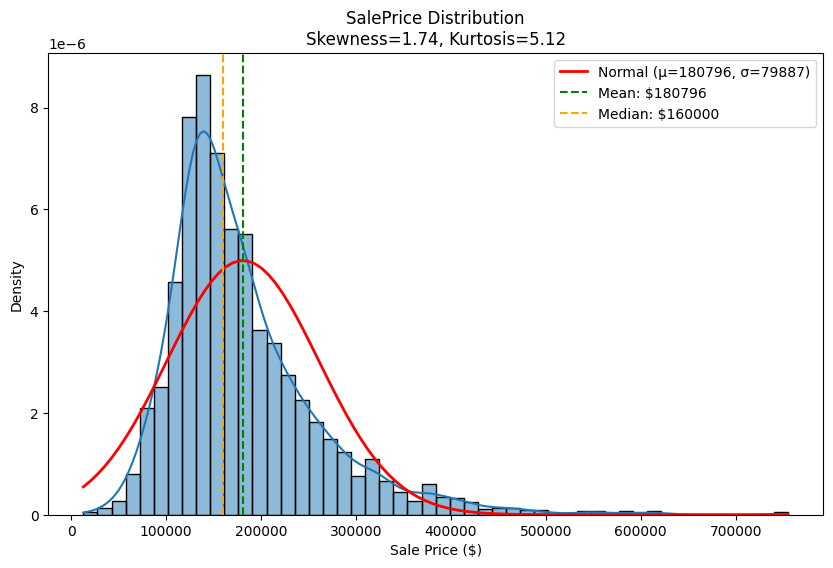

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Assuming df has SalePrice
skew_val = df['SalePrice'].skew()
kurt_val = df['SalePrice'].kurt()

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df['SalePrice'], bins=50, kde=True, stat='density', ax=ax)

# Add normal curve for comparison
x = np.linspace(df['SalePrice'].min(), df['SalePrice'].max(), 100)
normal_pdf = stats.norm.pdf(x, df['SalePrice'].mean(), df['SalePrice'].std())
ax.plot(x, normal_pdf, 'r-', lw=2, label=f'Normal (μ={df["SalePrice"].mean():.0f}, σ={df["SalePrice"].std():.0f})')

ax.set_title(f'SalePrice Distribution\nSkewness={skew_val:.2f}, Kurtosis={kurt_val:.2f}')
ax.set_xlabel('Sale Price ($)')
ax.set_ylabel('Density')
ax.legend()
ax.axvline(df['SalePrice'].mean(), color='g', linestyle='--', label=f'Mean: ${df["SalePrice"].mean():.0f}')
ax.axvline(df['SalePrice'].median(), color='orange', linestyle='--', label=f'Median: ${df["SalePrice"].median():.0f}')
ax.legend()
plt.show()

In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Miscellanious files/EDA_Basics.ipynb"